# Chapter 35 Lab — Dynamic Causal Models (Python)

In this lab you will build the core logic of dynamic causal modeling (DCM) by hand, with no SPM or DCM toolbox required. We follow a four-step arc:

1. **Simulate a two-region bilinear neuronal system**, $\dot{z} = (A + u_2 B^{(2)})z + Cu_1$, in which a modulatory input $u_2$ strengthens the $z_1 \to z_2$ connection
2. **Apply a hemodynamic observation model** — convolve the latent neuronal states with an HRF and sample at the TR — to produce noisy "observed" BOLD signals
3. **Invert two candidate generative models** ("modulation" vs. "no modulation") by least squares, playing the role of DCM's Bayesian estimation
4. **Compare the models with BIC**, a simple stand-in for the log model evidence, and verify the comparison also behaves correctly when the true data contain *no* modulation

Because we simulate with known ground truth, you can watch the inversion machinery recover the true coupling parameters — and watch model comparison pick the right network structure.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch35-dynamic-causal-models.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.optimize import minimize

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## 1. A two-region bilinear neuronal model

The neuronal level of a DCM for fMRI uses the bilinear state equation

$$
\dot{z} = \Big(A + \sum_{j} u_j B^{(j)}\Big) z + C u
$$

with three coefficient matrices playing distinct roles:

- $A$ — **intrinsic connectivity**: directional coupling among regions in the absence of input. Here region 1 projects to region 2 with weight $a_{21} = 0.3$, and each region has a self-decay term ($-0.4$ on the diagonal) so activity dies away without input.
- $B^{(2)}$ — **modulatory coupling**: how input $u_2$ *changes* connections. Here $u_2$ adds $b_{21} = 0.5$ to the $z_1 \to z_2$ path — the connection is gated by context.
- $C$ — **driving inputs**: how inputs directly excite regions. Here $u_1$ (brief stimulus pulses) drives region 1 only.

Input $u_1$ is a train of 1-second pulses (like stimuli); $u_2$ is a sustained block "context" (like attention) alternating OFF/ON in 60-second blocks. This mirrors Figure 35.1 in the chapter.

In [2]:
dt, T = 0.1, 300.0                # integration step (s), total time (s)
t = np.arange(0, T, dt)
n = t.size

# Experimental inputs
u1 = ((t % 20) < 1).astype(float)          # 1-s driving pulse every 20 s
u2 = ((t // 60) % 2 == 1).astype(float)    # alternating 60-s modulatory blocks

# Bilinear model parameters (ground truth)
A  = np.array([[-0.4, 0.0],
               [ 0.3, -0.4]])   # intrinsic coupling: z1 -> z2 = 0.3
B2 = np.array([[0.0, 0.0],
               [0.5, 0.0]])     # u2 adds 0.5 to the z1 -> z2 path
C  = np.array([1.0, 0.0])       # u1 drives region 1 only

print("Effective z1 -> z2 coupling: OFF blocks =", A[1, 0],
      "| ON blocks =", A[1, 0] + B2[1, 0])

Effective z1 -> z2 coupling: OFF blocks = 0.3 | ON blocks = 0.8


## 2. Simulate the latent neuronal dynamics

We integrate the differential equation with the simple Euler method: at each small time step, $z_{t+\Delta t} = z_t + \Delta t \cdot \dot{z}_t$. During modulation-ON blocks the effective $z_1 \to z_2$ coupling is $0.3 + 0.5 = 0.8$ rather than $0.3$, so region 2 should respond much more strongly to the *same* driving pulses.

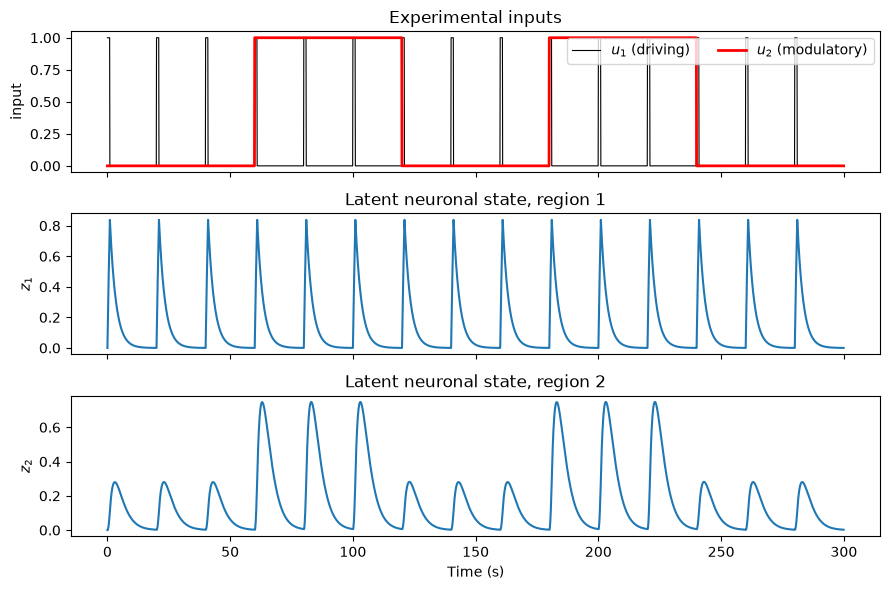

In [3]:
z = np.zeros((n, 2))
for i in range(n - 1):                     # Euler integration of dz/dt
    dz = (A + u2[i] * B2) @ z[i] + C * u1[i]
    z[i + 1] = z[i] + dt * dz

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, u1, "k", lw=0.8, label="$u_1$ (driving)")
axes[0].plot(t, u2, "r", lw=2, label="$u_2$ (modulatory)")
axes[0].set_ylabel("input"); axes[0].legend(loc="upper right", ncol=2)
axes[0].set_title("Experimental inputs")
axes[1].plot(t, z[:, 0]); axes[1].set_ylabel("$z_1$")
axes[1].set_title("Latent neuronal state, region 1")
axes[2].plot(t, z[:, 1]); axes[2].set_ylabel("$z_2$")
axes[2].set_title("Latent neuronal state, region 2")
axes[2].set_xlabel("Time (s)")
fig.tight_layout()

Region 1 responds identically to every pulse — its dynamics do not involve $u_2$. Region 2 tells the DCM story: the same input pulses produce much larger responses whenever the modulatory context is ON. Let's quantify that by comparing region 2's peak response per pulse in ON versus OFF blocks.

In [4]:
peaks_on, peaks_off = [], []
for onset in np.arange(0, T, 20):          # one pulse every 20 s
    window = (t >= onset) & (t < onset + 15)
    peak = z[window, 1].max()
    if u2[np.searchsorted(t, onset + 1)] == 1:
        peaks_on.append(peak)
    else:
        peaks_off.append(peak)

print(f"Mean peak z2 response, modulation OFF: {np.mean(peaks_off):.3f}")
print(f"Mean peak z2 response, modulation ON : {np.mean(peaks_on):.3f}")
print(f"Ratio ON/OFF: {np.mean(peaks_on) / np.mean(peaks_off):.2f}")

Mean peak z2 response, modulation OFF: 0.281
Mean peak z2 response, modulation ON : 0.747
Ratio ON/OFF: 2.66


## 3. Hemodynamic observation model: from $z$ to BOLD

We never observe $z$ directly. In a real DCM, each region's neuronal state passes through an **extended Balloon model** — differential equations for a vasodilatory signal, blood inflow, blood volume, and deoxyhemoglobin content, with region-specific parameters shrunk toward canonical values by priors. The predicted BOLD signal is a nonlinear function of volume and deoxyhemoglobin.

As a simple stand-in that captures the essential point — *the observation is a sluggish, blurred transform of neuronal activity* — we convolve $z$ with a canonical double-gamma HRF, sample every TR = 2 s, and add measurement noise:

$$
y_k = (z_k \ast h)(t)\Big|_{t = \text{TR grid}} + \varepsilon
$$

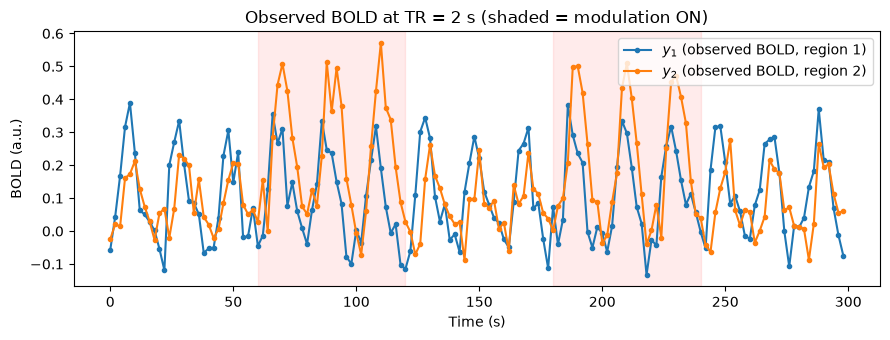

In [5]:
# Canonical double-gamma HRF on the fine time grid
hrf_t = np.arange(0, 30, dt)
hrf = gamma.pdf(hrf_t, 6) - gamma.pdf(hrf_t, 16) / 6

TR = 2.0
step = int(TR / dt)                        # fine samples per TR
t_TR = t[::step]                           # acquisition times
n_obs = t_TR.size

def bold(z_neural):
    """Hemodynamic observation model: HRF convolution + sampling at the TR."""
    return np.convolve(z_neural, hrf)[:n][::step] * dt

rng = np.random.default_rng(35)
noise_sd = 0.05
y1 = bold(z[:, 0]) + noise_sd * rng.standard_normal(n_obs)
y2 = bold(z[:, 1]) + noise_sd * rng.standard_normal(n_obs)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_TR, y1, "o-", ms=3, label="$y_1$ (observed BOLD, region 1)")
ax.plot(t_TR, y2, "o-", ms=3, label="$y_2$ (observed BOLD, region 2)")
for start in (60, 180):                    # shade modulation-ON blocks
    ax.axvspan(start, start + 60, color="red", alpha=0.08)
ax.set_xlabel("Time (s)"); ax.set_ylabel("BOLD (a.u.)")
ax.set_title("Observed BOLD at TR = 2 s (shaded = modulation ON)")
ax.legend(loc="upper right")
fig.tight_layout()

These two noisy time series are what an experimenter actually gets. Notice that the modulation effect survives the hemodynamic blur — region 2's responses are larger in the shaded blocks — but the crisp neuronal dynamics are hidden. Recovering the coupling parameters from $y$ is exactly the *model inversion* problem DCM solves.

## 4. Invert two candidate generative models

Now we switch roles: pretend we do not know the truth and ask which of two hypotheses better explains region 2's data.

- **Model 1 ("modulation")**: $\dot{z}_2 = (a_{21} + b_{21} u_2)\, z_1 + a_{22} z_2$, with $a_{21}$ and $b_{21}$ free ($k = 2$ parameters)
- **Model 0 ("no modulation")**: same equation with $b_{21}$ fixed at 0 ($k = 1$ parameter)

Both are *generative*: for candidate parameters we simulate the neuronal dynamics, apply the observation model, and compare the predicted BOLD to the data. Real DCM inverts the full model with Bayesian (EM) estimation and shrinkage priors; our cheap stand-in minimizes the residual sum of squares (RSS) with a general-purpose optimizer.

(One simplification: because there is no $z_2 \to z_1$ connection, $z_1$'s dynamics do not depend on $a_{21}$ or $b_{21}$, so we hold the simulated $z_1$ fixed and refit only region 2. We also treat the self-decay $a_{22}$ as known.)

In [6]:
a22 = -0.4                                  # self-decay, treated as known
z1_true = z[:, 0]

def simulate_z2(a21, b21):
    """Simulate region 2's neuronal state for candidate coupling parameters."""
    z2 = np.zeros(n)
    drive = (a21 + b21 * u2) * z1_true
    for i in range(n - 1):
        z2[i + 1] = z2[i] + dt * (drive[i] + a22 * z2[i])
    return z2

def predict_bold(a21, b21):
    return bold(simulate_z2(a21, b21))

def rss(theta, modulation=True):
    a21 = theta[0]
    b21 = theta[1] if modulation else 0.0
    return np.sum((y2 - predict_bold(a21, b21)) ** 2)

def fit_dcm(modulation=True):
    """Least-squares 'inversion' of one candidate model. Returns (params, RSS, k)."""
    x0 = [0.2, 0.2] if modulation else [0.2]
    res = minimize(rss, x0, args=(modulation,), method="Nelder-Mead")
    return res.x, res.fun, len(x0)

theta1, rss1, k1 = fit_dcm(modulation=True)
theta0, rss0, k0 = fit_dcm(modulation=False)

print(f"Modulation model:    a21 = {theta1[0]:.3f}, b21 = {theta1[1]:.3f} "
      f"(truth: 0.300, 0.500) | RSS = {rss1:.3f}")
print(f"No-modulation model: a21 = {theta0[0]:.3f}"
      f"                          | RSS = {rss0:.3f}")

Modulation model:    a21 = 0.314, b21 = 0.490 (truth: 0.300, 0.500) | RSS = 0.363
No-modulation model: a21 = 0.509                          | RSS = 1.474


The modulation model recovers the true coupling parameters closely. The no-modulation model is forced to compromise: a single coupling strength must average over the ON and OFF blocks, so it under-predicts responses in ON blocks and over-predicts in OFF blocks. Let's look at the fits.

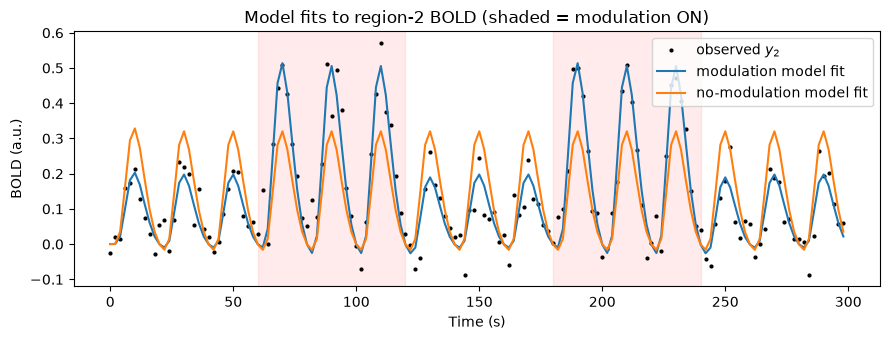

In [7]:
pred1 = predict_bold(*theta1)
pred0 = predict_bold(theta0[0], 0.0)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_TR, y2, "k.", ms=4, label="observed $y_2$")
ax.plot(t_TR, pred1, lw=1.5, label="modulation model fit")
ax.plot(t_TR, pred0, lw=1.5, label="no-modulation model fit")
for start in (60, 180):
    ax.axvspan(start, start + 60, color="red", alpha=0.08)
ax.set_xlabel("Time (s)"); ax.set_ylabel("BOLD (a.u.)")
ax.set_title("Model fits to region-2 BOLD (shaded = modulation ON)")
ax.legend(loc="upper right")
fig.tight_layout()

## 5. Compare models with BIC — a simple evidence proxy

In DCM, competing network structures are compared through the **model evidence** $p(y \mid m)$ — the probability of the data under the model, integrating over its parameters — and the **Bayes factor** $BF_{10} = p(y \mid m_1)/p(y \mid m_0)$. The evidence automatically penalizes complexity: a model with extra parameters must earn its keep.

We use the Bayesian Information Criterion as a rough, easy-to-compute proxy for $-2 \log p(y \mid m)$:

$$
\mathrm{BIC} = n \log\!\big(\mathrm{RSS}/n\big) + k \log n
$$

Lower BIC is better, and $\exp\!\big(\Delta \mathrm{BIC} / 2\big)$ approximates the Bayes factor. (SPM's DCM uses a variational *free-energy* approximation to the log evidence, which plays the same role with more care.)

In [8]:
def bic(rss_val, k):
    return n_obs * np.log(rss_val / n_obs) + k * np.log(n_obs)

bic1, bic0 = bic(rss1, k1), bic(rss0, k0)
dbic = bic0 - bic1

print(f"BIC (modulation)    = {bic1:.1f}   (k = {k1})")
print(f"BIC (no modulation) = {bic0:.1f}   (k = {k0})")
print(f"dBIC (no-mod - mod) = {dbic:.1f}")
print(f"Approximate Bayes factor in favor of modulation: exp(dBIC/2) = {np.exp(dbic / 2):.3g}")

BIC (modulation)    = -893.4   (k = 2)
BIC (no modulation) = -688.4   (k = 1)
dBIC (no-mod - mod) = 205.0
Approximate Bayes factor in favor of modulation: exp(dBIC/2) = 3.26e+44


A decisively positive $\Delta$BIC: the data overwhelmingly favor the model in which $u_2$ modulates the $z_1 \to z_2$ connection. This is the DCM way of concluding, for example, that "attention increases the effective connectivity from V1 to V5" — the claim is about a *parameter of a generative neuronal model*, not about a correlation between observed time series.

## 6. Control analysis: data generated *without* modulation

Model comparison must also protect us from over-claiming. If the true system has no modulation, the extra $b_{21}$ parameter can only chase noise — the fit improves negligibly while the complexity penalty grows — so BIC should now favor the simpler model. Let's verify.

In [9]:
# Regenerate region-2 data with b21 = 0 (no true modulation)
z2_null = simulate_z2(0.3, 0.0)
y2_null = bold(z2_null) + noise_sd * rng.standard_normal(n_obs)

def rss_null(theta, modulation=True):
    a21 = theta[0]
    b21 = theta[1] if modulation else 0.0
    return np.sum((y2_null - predict_bold(a21, b21)) ** 2)

res1n = minimize(rss_null, [0.2, 0.2], args=(True,), method="Nelder-Mead")
res0n = minimize(rss_null, [0.2], args=(False,), method="Nelder-Mead")

bic1n, bic0n = bic(res1n.fun, 2), bic(res0n.fun, 1)
print(f"Estimated b21 under the modulation model: {res1n.x[1]:.3f} (truth: 0)")
print(f"BIC (modulation)    = {bic1n:.1f}")
print(f"BIC (no modulation) = {bic0n:.1f}")
print(f"dBIC (no-mod - mod) = {bic0n - bic1n:.1f}  ->  "
      f"{'modulation' if bic0n > bic1n else 'no-modulation'} model preferred")

Estimated b21 under the modulation model: 0.001 (truth: 0)
BIC (modulation)    = -909.2
BIC (no modulation) = -914.2
dBIC (no-mod - mod) = -5.0  ->  no-modulation model preferred


When the truth contains no modulation, the estimated $b_{21}$ hovers near zero, the RSS improvement is tiny, and the $\log n$ complexity penalty tips the balance toward the simpler model — evidence-based comparison selects the right structure in both directions.

## Wrap-up: from this toy model to real DCM

You have now implemented, in miniature, the full DCM logic: a **generative model** (bilinear neuronal dynamics plus a hemodynamic observation model), **model inversion** (estimating coupling parameters from observed BOLD), and **evidence-based model comparison** (adjudicating between network hypotheses). What the real thing adds:

- **A biophysical hemodynamic model.** SPM's DCM replaces our fixed canonical HRF with an extended Balloon model per region — vasodilatory signal, inflow, volume, and deoxyhemoglobin — whose five parameters are estimated with shrinkage priors, so regional hemodynamic differences are modeled rather than mistaken for neuronal effects.
- **Full Bayesian inversion.** Expectation–Maximization yields a posterior *distribution* over every parameter (not just point estimates), supporting probabilistic statements such as "the probability that this connection exceeds zero is 0.98".
- **Proper model evidence.** A variational free-energy approximation replaces BIC, and group inference proceeds via Parametric Empirical Bayes (PEB) — a second-level GLM on connection strengths that carries forward each participant's posterior uncertainty. Remember the key restriction: only models with the same regions can be compared.
- **A path to larger models.** Notice that in our model $\dot{z}_2$ was *linear* in $(a_{21}, b_{21})$ once $z_1$ was fixed — a hint of why *regression DCM* can recast estimation as Bayesian linear regression and scale toward whole-brain effective connectivity. Stochastic and spectral DCM extend the framework to resting-state data.

And carry the caveats with you: inferences are only as good as the specified model, omitted regions can masquerade as (or hide) connections, and classical DCM handles only small networks. DCM is best used to identify systems and pathways — not to prove causal claims.